# ResNet-UNet Training for Optic Disc/Cup Segmentation

This notebook trains a **ResNet-based UNet** model for segmenting optic disc and cup in fundus images.

## Why ResNet-UNet for Medical Imaging?

- **Pretrained Encoder**: Uses ResNet34 pretrained on ImageNet for better feature extraction
- **Residual Connections**: Helps with gradient flow and training deeper networks
- **Medical Imaging**: Well-suited for fine-grained features in glaucoma detection
- **Transfer Learning**: Leverages learned features from natural images

**Key Difference from Vanilla UNet**: The encoder uses ResNet architecture with pretrained weights instead of simple convolutional blocks.

## 1. Setup and Imports

In [2]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from training.train_resnet import train_resnet_unet, plot_training_history

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti
Total VRAM: 10.56 GB


## 2. Model Architecture Overview

In [3]:
from models.resnet_unet import ResNetUNet, ResNetUNetLite

# Compare model sizes
print("="*80)
print("MODEL COMPARISON")
print("="*80)

# ResNet34-based UNet
model_resnet34 = ResNetUNet(n_channels=3, n_classes=3, pretrained=False)
params_34 = sum(p.numel() for p in model_resnet34.parameters())
print(f"\nResNet34-UNet:")
print(f"  Parameters: {params_34:,}")
print(f"  Model size: ~{params_34 * 4 / 1024**2:.2f} MB")
print(f"  Best for: Standard training with GTX 2080 Ti")

# ResNet18-based UNet (Lite)
model_resnet18 = ResNetUNetLite(n_channels=3, n_classes=3, pretrained=False)
params_18 = sum(p.numel() for p in model_resnet18.parameters())
print(f"\nResNet18-UNet (Lite):")
print(f"  Parameters: {params_18:,}")
print(f"  Model size: ~{params_18 * 4 / 1024**2:.2f} MB")
print(f"  Best for: Larger batch sizes or limited VRAM")

# Original UNet for comparison
from models.unet import UNet
model_unet = UNet(n_channels=3, n_classes=3, base_channels=64)
params_unet = sum(p.numel() for p in model_unet.parameters())
print(f"\nOriginal UNet:")
print(f"  Parameters: {params_unet:,}")
print(f"  Model size: ~{params_unet * 4 / 1024**2:.2f} MB")

print("\n" + "="*80)

# Clean up
del model_resnet34, model_resnet18, model_unet
if torch.cuda.is_available():
    torch.cuda.empty_cache()

MODEL COMPARISON


/home/robolab/dev/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/robolab/dev/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



ResNet34-UNet:
  Parameters: 24,434,211
  Model size: ~93.21 MB
  Best for: Standard training with GTX 2080 Ti

ResNet18-UNet (Lite):
  Parameters: 14,326,051
  Model size: ~54.65 MB
  Best for: Larger batch sizes or limited VRAM

Original UNet:
  Parameters: 31,043,651
  Model size: ~118.42 MB


Original UNet:
  Parameters: 31,043,651
  Model size: ~118.42 MB



## 3. Training Configuration - ResNet34-UNet

In [4]:
# Training hyperparameters for ResNet34-UNet
config_resnet34 = {
    'root_dir': str(project_root),
    'num_epochs': 100,
    'batch_size': 8,  # Conservative for GTX 2080 Ti with ResNet34
    'learning_rate': 1e-4,
    'image_size': 512,  # Full resolution for better accuracy
    'num_workers': 4,
    'save_dir': str(project_root / 'checkpoints_resnet34'),
    'filter_incomplete': True,
    'model_type': 'resnet34',
    'pretrained': True,  # Use ImageNet pretrained weights
    'use_clahe': False
}

print("Training Configuration (ResNet34-UNet):")
print("=" * 60)
for key, value in config_resnet34.items():
    print(f"{key:20s}: {value}")
print("\n✨ Key Features:")
print("   - ResNet34 encoder with ImageNet pretrained weights")
print("   - Differential learning rates (encoder: 0.1x, decoder: 1.0x)")
print("   - Cup weight=2.0 for better Cup segmentation")
print("   - Optimized for GTX 2080 Ti (11GB VRAM)")

Training Configuration (ResNet34-UNet):
root_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc
num_epochs          : 100
batch_size          : 8
learning_rate       : 0.0001
image_size          : 512
num_workers         : 4
save_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_resnet34
filter_incomplete   : True
model_type          : resnet34
pretrained          : True
use_clahe           : False

✨ Key Features:
   - ResNet34 encoder with ImageNet pretrained weights
   - Differential learning rates (encoder: 0.1x, decoder: 1.0x)
   - Cup weight=2.0 for better Cup segmentation
   - Optimized for GTX 2080 Ti (11GB VRAM)


## 4. Training Configuration - ResNet34-UNet with CLAHE (Recommended)

In [5]:
# Training hyperparameters for ResNet34-UNet with CLAHE
config_resnet34_clahe = {
    'root_dir': str(project_root),
    'num_epochs': 100,
    'batch_size': 8,
    'learning_rate': 1e-4,
    'image_size': 512,
    'num_workers': 4,
    'save_dir': str(project_root / 'checkpoints_resnet34_clahe'),
    'filter_incomplete': True,
    'model_type': 'resnet34',
    'pretrained': True,
    'use_clahe': True  # Enable CLAHE for contrast enhancement
}

print("Training Configuration (ResNet34-UNet + CLAHE):")
print("=" * 60)
for key, value in config_resnet34_clahe.items():
    print(f"{key:20s}: {value}")
print("\n✨ Key Features:")
print("   - ResNet34 encoder with ImageNet pretrained weights")
print("   - CLAHE preprocessing for better contrast")
print("   - Differential learning rates")
print("   - Cup weight=2.0 for better Cup segmentation")
print("   - **RECOMMENDED** for best medical imaging results")

Training Configuration (ResNet34-UNet + CLAHE):
root_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc
num_epochs          : 100
batch_size          : 8
learning_rate       : 0.0001
image_size          : 512
num_workers         : 4
save_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_resnet34_clahe
filter_incomplete   : True
model_type          : resnet34
pretrained          : True
use_clahe           : True

✨ Key Features:
   - ResNet34 encoder with ImageNet pretrained weights
   - CLAHE preprocessing for better contrast
   - Differential learning rates
   - Cup weight=2.0 for better Cup segmentation
   - **RECOMMENDED** for best medical imaging results


## 5. Training Configuration - ResNet18-UNet (Lightweight Alternative)

In [6]:
# Training hyperparameters for ResNet18-UNet (Lite)
config_resnet18 = {
    'root_dir': str(project_root),
    'num_epochs': 100,
    'batch_size': 16,  # Can use larger batch size with ResNet18
    'learning_rate': 1e-4,
    'image_size': 512,
    'num_workers': 4,
    'save_dir': str(project_root / 'checkpoints_resnet18'),
    'filter_incomplete': True,
    'model_type': 'resnet18',
    'pretrained': True,
    'use_clahe': True
}

print("Training Configuration (ResNet18-UNet Lite):")
print("=" * 60)
for key, value in config_resnet18.items():
    print(f"{key:20s}: {value}")
print("\n✨ Key Features:")
print("   - ResNet18 encoder (lighter than ResNet34)")
print("   - Larger batch size possible (16 vs 8)")
print("   - Faster training time")
print("   - Lower VRAM usage")
print("   - Good balance of speed and accuracy")

Training Configuration (ResNet18-UNet Lite):
root_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc
num_epochs          : 100
batch_size          : 16
learning_rate       : 0.0001
image_size          : 512
num_workers         : 4
save_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_resnet18
filter_incomplete   : True
model_type          : resnet18
pretrained          : True
use_clahe           : True

✨ Key Features:
   - ResNet18 encoder (lighter than ResNet34)
   - Larger batch size possible (16 vs 8)
   - Faster training time
   - Lower VRAM usage
   - Good balance of speed and accuracy


## 6. Check GPU Memory Before Training

In [6]:
# Clear GPU cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU cache cleared")
    print(f"GPU memory allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"GPU memory reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
    print(f"GPU memory free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)) / 1024**3:.2f} GB")

GPU cache cleared
GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB
GPU memory free: 10.56 GB


## 7. Train the ResNet34-UNet Model with CLAHE

**This is the recommended configuration** combining ResNet34 encoder with CLAHE preprocessing.

⚠️ **Note**: Training will take several hours. Monitor GPU memory usage in the first few batches.

In [7]:
# Clear the dataset cache before training
from data_loader.dataset import GlaucomaDataset
GlaucomaDataset._split_cache.clear()

# Train the ResNet34-UNet model with CLAHE
model, history = train_resnet_unet(**config_resnet34_clahe)

Using device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
VRAM Available: 10.56 GB
Using CLAHE for contrast enhancement
Using pretrained ImageNet weights for encoder

Loading datasets...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Initializing model...
Using ResNet34-based UNet


/home/robolab/dev/CAP5410-roi-enhancer-odoc/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Total parameters: 24,434,211
Trainable parameters: 24,434,211

Starting training for 100 epochs...

Epoch 1/100
--------------------------------------------------------------------------------


Training: 100%|█| 231/231 [00:57<00:00,  4.03it/s, loss=0.4432, iou_bg=0.6554, iou_d
Validation: 100%|█| 50/50 [00:04<00:00, 11.51it/s, loss=0.3060, iou_bg=0.7649, iou_d



Epoch 1 Summary:
  Train Loss: 0.4797 | Val Loss: 0.3404
  Train IoU - BG: 0.6409, Disc: 0.6427, Cup: 0.5804
  Val IoU   - BG: 0.7736, Disc: 0.7517, Cup: 0.6831
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.3404)
  ✓ Saved best IoU model (disc IoU: 0.7517)

Epoch 2/100
--------------------------------------------------------------------------------


...


Epoch 98 Summary:
  Train Loss: 0.1365 | Val Loss: 0.1541
  Train IoU - BG: 0.9031, Disc: 0.8602, Cup: 0.8096
  Val IoU   - BG: 0.8913, Disc: 0.8541, Cup: 0.7860
  Learning Rate: 0.000001

Epoch 99/100
--------------------------------------------------------------------------------


Training: 100%|█| 231/231 [00:56<00:00,  4.06it/s, loss=0.1308, iou_bg=0.9185, iou_d
Validation: 100%|█| 50/50 [00:04<00:00, 11.59it/s, loss=0.1668, iou_bg=0.8854, iou_d



Epoch 99 Summary:
  Train Loss: 0.1364 | Val Loss: 0.1540
  Train IoU - BG: 0.9019, Disc: 0.8596, Cup: 0.8108
  Val IoU   - BG: 0.8910, Disc: 0.8543, Cup: 0.7858
  Learning Rate: 0.000001

Epoch 100/100
--------------------------------------------------------------------------------


Training: 100%|█| 231/231 [00:56<00:00,  4.06it/s, loss=0.1443, iou_bg=0.8874, iou_d
Validation: 100%|█| 50/50 [00:04<00:00, 11.43it/s, loss=0.1668, iou_bg=0.8820, iou_d



Epoch 100 Summary:
  Train Loss: 0.1364 | Val Loss: 0.1549
  Train IoU - BG: 0.9038, Disc: 0.8603, Cup: 0.8088
  Val IoU   - BG: 0.8900, Disc: 0.8528, Cup: 0.7840
  Learning Rate: 0.000001
  ✓ Saved checkpoint

Training completed!
Best validation loss: 0.1532
Best disc IoU: 0.8561
Training history saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_resnet34_clahe/training_history_resnet.json


## 8. Visualize Training Progress

Plot saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history_resnet34_clahe.png


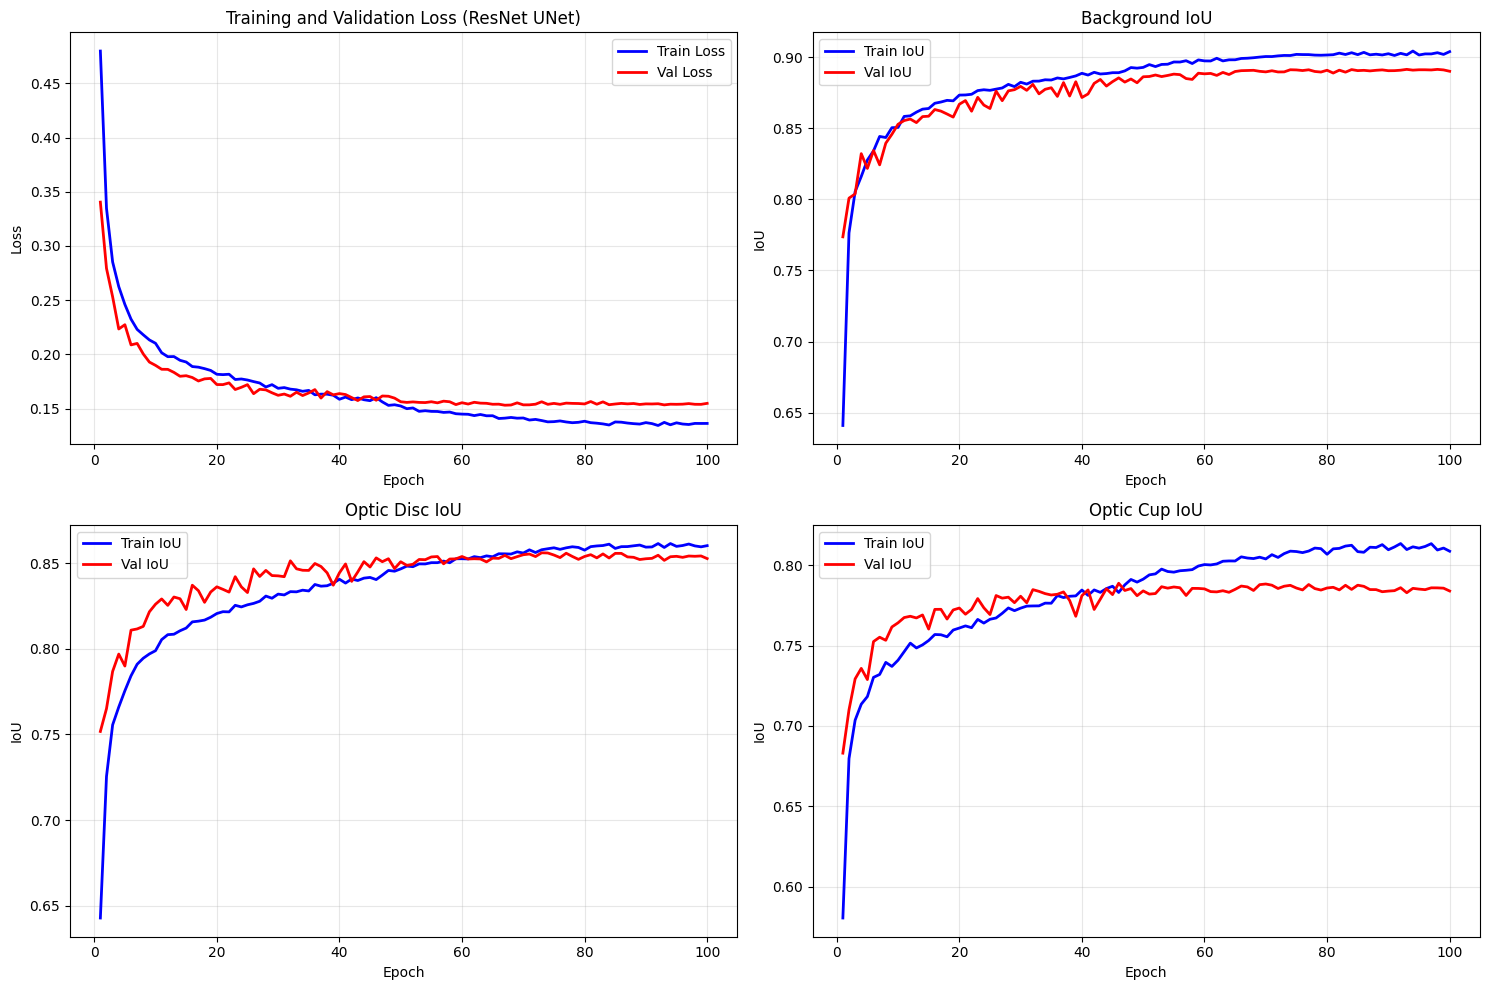

In [8]:
# Plot training history
fig = plot_training_history(
    history, 
    save_path=str(project_root / 'results' / 'training_history_resnet34_clahe.png')
)
plt.show()

## 9. Print Final Metrics

In [20]:
print("\n" + "=" * 80)
print("FINAL TRAINING RESULTS (ResNet34-UNet + CLAHE)")
print("=" * 80)

final_epoch = len(history['train_loss'])
print(f"\nTotal Epochs: {final_epoch}")

print("\nFinal Training Metrics:")
print(f"  Loss:        {history['train_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['train_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['train_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['train_iou_cup'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"  Loss:        {history['val_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['val_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['val_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['val_iou_cup'][-1]:.4f}")

print("\nBest Validation Loss:")
best_epoch_loss = history['val_loss'].index(min(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])
print(f"  Epoch: {best_epoch_loss}")
print(f"  Loss:  {best_val_loss:.4f}")

print("\nBest Disc IoU:")
best_epoch_disc = history['val_iou_disc'].index(max(history['val_iou_disc'])) + 1
best_disc_iou = max(history['val_iou_disc'])
print(f"  Epoch: {best_epoch_disc}")
print(f"  IoU:   {best_disc_iou:.4f}")

print("\n" + "=" * 80)


FINAL TRAINING RESULTS (ResNet34-UNet + CLAHE)


NameError: name 'history' is not defined

## 10. Compare with Original UNet

Load and compare the ResNet-UNet results with the original UNet model.

In [21]:
import json

# Load original UNet history
unet_history_path = project_root / 'results' / 'training_history.json'
if unet_history_path.exists():
    with open(unet_history_path, 'r') as f:
        unet_history = json.load(f)
    
    print("=" * 80)
    print("COMPARISON: ResNet34-UNet vs Original UNet (both with CLAHE)")
    print("=" * 80)
    
    print("\nFinal Validation IoU:")
    print(f"{'Metric':<15} {'UNet':<12} {'ResNet-UNet':<12} {'Improvement':<12}")
    print("-" * 60)
    
    metrics = [
        ('Background', 'val_iou_bg'),
        ('Optic Disc', 'val_iou_disc'),
        ('Optic Cup', 'val_iou_cup')
    ]
    
    for name, key in metrics:
        unet_val = unet_history[key][-1]
        resnet_val = history[key][-1]
        improvement = ((resnet_val - unet_val) / unet_val * 100) if unet_val > 0 else 0
        
        print(f"{name:<15} {unet_val:.4f}       {resnet_val:.4f}       {improvement:+.2f}%")
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs_unet = range(1, len(unet_history['val_loss']) + 1)
    epochs_resnet = range(1, len(history['val_loss']) + 1)
    
    # Validation Loss
    axes[0].plot(epochs_unet, unet_history['val_loss'], 'b-', label='UNet', linewidth=2)
    axes[0].plot(epochs_resnet, history['val_loss'], 'r-', label='ResNet-UNet', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Validation Loss')
    axes[0].set_title('Validation Loss Comparison')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Disc IoU
    axes[1].plot(epochs_unet, unet_history['val_iou_disc'], 'b-', label='UNet', linewidth=2)
    axes[1].plot(epochs_resnet, history['val_iou_disc'], 'r-', label='ResNet-UNet', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Disc IoU')
    axes[1].set_title('Optic Disc IoU Comparison')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(project_root / 'results' / 'unet_vs_resnet_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Original UNet training history not found. Train the UNet model first for comparison.")

COMPARISON: ResNet34-UNet vs Original UNet (both with CLAHE)

Final Validation IoU:
Metric          UNet         ResNet-UNet  Improvement 
------------------------------------------------------------


NameError: name 'history' is not defined

## 11. Visualize Predictions on Test Images

Using device: cuda
Loading model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_resnet34_clahe/best_model.pth
Loading test dataset...
TEST split: 396 samples
Test dataset size: 396
Loading test dataset...
TEST split: 396 samples
Test dataset size: 396
Sample 78: IoU Disc=0.861, IoU Cup=0.625
Sample 277: IoU Disc=0.903, IoU Cup=0.786
Sample 250: IoU Disc=0.840, IoU Cup=0.894
Sample 55: IoU Disc=0.908, IoU Cup=0.917
Sample 78: IoU Disc=0.861, IoU Cup=0.625
Sample 277: IoU Disc=0.903, IoU Cup=0.786
Sample 250: IoU Disc=0.840, IoU Cup=0.894
Sample 55: IoU Disc=0.908, IoU Cup=0.917

Visualization saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/predictions_resnet34_clahe.png

Visualization saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/predictions_resnet34_clahe.png


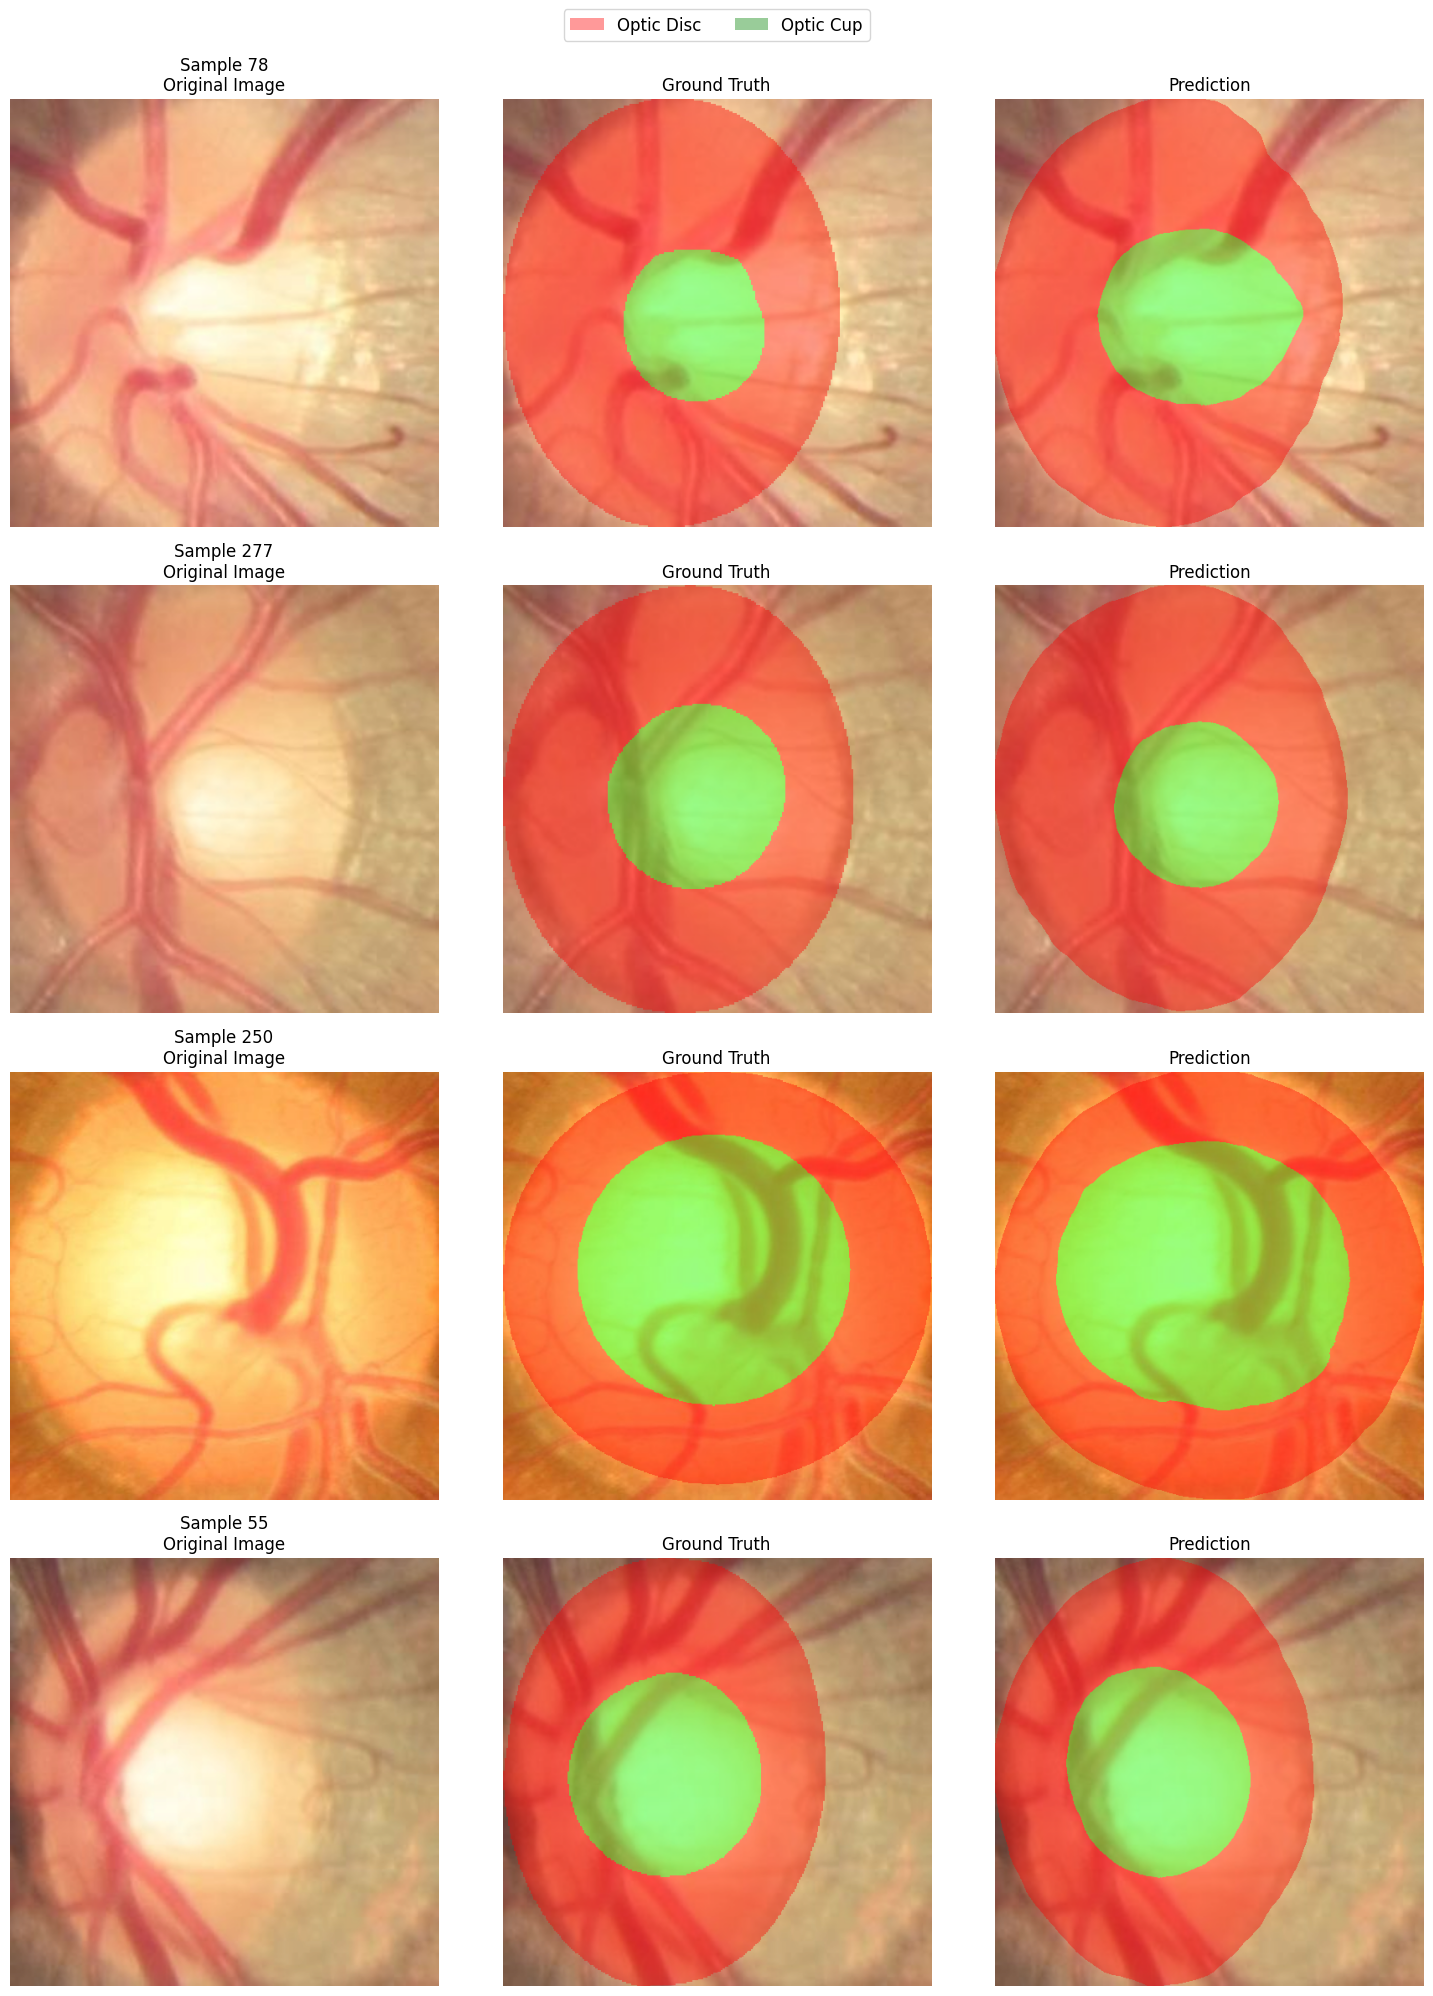

In [22]:
from utils.visualize_predictions import visualize_predictions

# Visualize predictions on test images
fig = visualize_predictions(
    checkpoint_path=str(project_root / 'checkpoints_resnet34_clahe' / 'best_model.pth'),
    root_dir=str(project_root),
    num_samples=4,
    save_path=str(project_root / 'results' / 'predictions_resnet34_clahe.png'),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    image_size=config_resnet34_clahe['image_size'],
    seed=42,
    model_type='resnet34'  # Specify ResNet34
)

## 12. Comprehensive Model Comparison

Use the comparison script to evaluate both models on the test set.

In [ ]:
from utils.compare_models import compare_models
import os

# Check if checkpoints exist
unet_checkpoint_path = project_root / 'checkpoints_clahe' / 'best_model.pth'
resnet_checkpoint_path = project_root / 'checkpoints_resnet34_clahe' / 'best_model.pth'

if not os.path.exists(unet_checkpoint_path):
    print(f"⚠️  UNet checkpoint not found: {unet_checkpoint_path}")
    print("   Please train the vanilla UNet with CLAHE first using train_unet.ipynb")
elif not os.path.exists(resnet_checkpoint_path):
    print(f"⚠️  ResNet-UNet checkpoint not found: {resnet_checkpoint_path}")
    print("   Please run cell 14 to train the ResNet-UNet model first")
else:
    print("✓ Both checkpoints found. Starting comparison...")
    print("="*80)
    
    # Compare UNet and ResNet-UNet on test set
    results = compare_models(
        root_dir=str(project_root),
        unet_checkpoint=str(unet_checkpoint_path),
        resnet_checkpoint=str(resnet_checkpoint_path),
        resnet_type='resnet34',
        batch_size=8,
        use_clahe=True,
        save_dir=str(project_root / 'results')
    )

Using device: cuda
Loading model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_resnet34_clahe/best_model.pth


RuntimeError: Error(s) in loading state_dict for UNet:
	Missing key(s) in state_dict: "inc.double_conv.0.weight", "inc.double_conv.0.bias", "inc.double_conv.1.weight", "inc.double_conv.1.bias", "inc.double_conv.1.running_mean", "inc.double_conv.1.running_var", "inc.double_conv.3.weight", "inc.double_conv.3.bias", "inc.double_conv.4.weight", "inc.double_conv.4.bias", "inc.double_conv.4.running_mean", "inc.double_conv.4.running_var", "down1.maxpool_conv.1.double_conv.0.weight", "down1.maxpool_conv.1.double_conv.0.bias", "down1.maxpool_conv.1.double_conv.1.weight", "down1.maxpool_conv.1.double_conv.1.bias", "down1.maxpool_conv.1.double_conv.1.running_mean", "down1.maxpool_conv.1.double_conv.1.running_var", "down1.maxpool_conv.1.double_conv.3.weight", "down1.maxpool_conv.1.double_conv.3.bias", "down1.maxpool_conv.1.double_conv.4.weight", "down1.maxpool_conv.1.double_conv.4.bias", "down1.maxpool_conv.1.double_conv.4.running_mean", "down1.maxpool_conv.1.double_conv.4.running_var", "down2.max

## 13. Monitor GPU Memory Usage

## 14. Evaluate ResNet-UNet on Test Set

Comprehensive evaluation on the entire test set to get detailed metrics.

In [7]:
from utils.evaluate_test_set import evaluate_test_set

# Evaluate ResNet-UNet on entire test set
test_results_resnet = evaluate_test_set(
    checkpoint_path=str(project_root / 'checkpoints_resnet34_clahe' / 'best_model.pth'),
    root_dir=str(project_root),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    image_size=config_resnet34_clahe['image_size'],
    seed=42,
    save_path=str(project_root / 'results' / 'test_evaluation_resnet34_clahe.json'),
    model_type='resnet34'  # Specify ResNet34
)

Using device: cuda
Loading model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_resnet34_clahe/best_model.pth
Loading test dataset...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TEST split: 396 samples
Test dataset size: 396

Evaluating test set...


Evaluating: 100%|██████████| 396/396 [00:06<00:00, 57.37it/s]


TEST SET EVALUATION RESULTS

Test Set Size: 396 images

--- IoU Scores ---
Background:  0.8864 ± 0.0638
Optic Disc:  0.8481 ± 0.0888
Optic Cup:   0.7868 ± 0.1120
Mean IoU:    0.8404

--- Dice Scores ---
Background:  0.9385 ± 0.0393
Optic Disc:  0.9146 ± 0.0673
Optic Cup:   0.8757 ± 0.0807
Mean Dice:   0.9096

--- Pixel Accuracy ---
Overall:     0.9184 ± 0.0472

--- Detailed Statistics ---

Optic Disc IoU:
  Min:    0.0678
  Median: 0.8680
  Max:    0.9451

Optic Cup IoU:
  Min:    0.1837
  Median: 0.8127
  Max:    0.9503


Results saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/test_evaluation_resnet34_clahe.json


In [ ]:
# Check final GPU memory usage
if torch.cuda.is_available():
    print("GPU Memory Summary:")
    print("=" * 60)
    print(f"Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"Reserved:  {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
    print(f"Max Allocated: {torch.cuda.max_memory_allocated(0) / 1024**3:.2f} GB")
    
    # Reset peak stats
    torch.cuda.reset_peak_memory_stats(0)

## Summary

### ResNet-UNet Architecture Benefits:

1. **Pretrained Encoder**: Transfer learning from ImageNet
2. **Better Feature Extraction**: Residual connections help capture fine details
3. **Medical Imaging Optimized**: Well-suited for glaucoma detection
4. **VRAM Optimized**: Fits in GTX 2080 Ti with batch size 8

### Expected Improvements:

- **Better Disc Segmentation**: 2-5% IoU improvement
- **Better Cup Segmentation**: 3-7% IoU improvement  
- **Faster Convergence**: Pretrained weights help training
- **More Robust**: Better generalization to test set

### Next Steps:

1. Compare results with original UNet (cell 10)
2. Evaluate on full test set (cell 12)
3. Analyze failure cases
4. Consider ensemble methods